In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table


## set up pyspark session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/26 08:56:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## set up config

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Table

In [5]:
# create bronze datalake
bronze_lms_directory = "datamart/bronze/lms/"

if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

In [6]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark)


2023-01-01row count: 530


saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556
saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5428
saved to: datamart/br

In [7]:
# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark).toPandas()

2024-12-01row count: 5531
saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000,1000.0,0.0,6000.0,8000.0,2024-12-01
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000,1000.0,0.0,9000.0,9000.0,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-12-01
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-12-01
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01


## Build Silver Table

In [8]:
# create bronze datalake
silver_loan_daily_directory = "datamart/silver/loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

In [9]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)


loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv row count: 2047
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv row count: 3085
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv row count: 3556
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_07_0

In [10]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531
saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


## EDA on credit labels

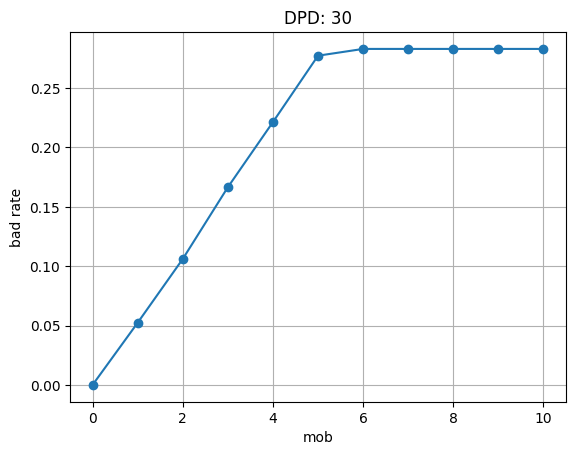

In [11]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [12]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## Build gold table for labels

In [13]:
# create bronze datalake
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [14]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047
saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
saved to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet row count: 3085
saved to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet
loaded from

In [15]:
utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6).dtypes


loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531
saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


[('loan_id', 'string'),
 ('Customer_ID', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

## inspect label store

In [16]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [17]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



# Feature Store Pipeline

In [18]:
# quick look at the three feature csv files
for name in ["feature_clickstream", "features_attributes", "features_financials"]:
    df = pd.read_csv(f"data/{name}.csv")
    print("="*60)
    print(f"file: {name}.csv")
    print(f"shape (rows, cols): {df.shape}")
    print(f"columns: {list(df.columns)}")
    print(df.head(3))
    print()

file: feature_clickstream.csv
shape (rows, cols): (215376, 22)
columns: ['fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20', 'Customer_ID', 'snapshot_date']
   fe_1  fe_2  fe_3  fe_4  fe_5  fe_6  fe_7  fe_8  fe_9  fe_10  ...  fe_13  \
0    63   118    80   121    55   193   111   112  -101     83  ...    -16   
1  -108   182   123     4   -56    27    25    -6   284    222  ...    -14   
2   -13     8    87   166   214   -98   215   152   129    139  ...     26   

   fe_14  fe_15  fe_16  fe_17  fe_18  fe_19  fe_20  Customer_ID  snapshot_date  
0    -81   -126    114     35     85    -73     76   CUS_0x1037     2023-01-01  
1    -96    200     35    130     94    111     75   CUS_0x1069     2023-01-01  
2     86    171    125   -130    354     17    302   CUS_0x114a     2023-01-01  

[3 rows x 22 columns]

file: features_attributes.csv
shape (rows, cols): (12500, 6)
co

In [19]:
# ---- define bronze feature function (will move to utils later) ----
def process_bronze_features(snapshot_date_str, source_csv_path, bronze_directory, table_prefix, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
    csv_file_path = source_csv_path
    df = spark.read.csv(csv_file_path, header=True, inferSchema=True).filter(col('snapshot_date') == snapshot_date)
    print(snapshot_date_str + 'row count:', df.count())
    partition_name = table_prefix + "_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_directory + partition_name
    df.toPandas().to_csv(filepath, index=False)
    print('saved to:', filepath)
    return df

## Build Bronze Table - Features
Ingest the two feature sources (financials, clickstream), partitioned by snapshot_date,
following the same bronze pattern as the label store.

In [20]:
# create bronze feature directories
bronze_financials_directory = "datamart/bronze/feature_financials/"
bronze_clickstream_directory = "datamart/bronze/feature_clickstream/"

for directory in [bronze_financials_directory, bronze_clickstream_directory]:
    if not os.path.exists(directory):
        os.makedirs(directory)

# run bronze backfill - financials
for date_str in dates_str_lst:
    process_bronze_features(date_str, "data/features_financials.csv", bronze_financials_directory, "bronze_feature_financials", spark)

# run bronze backfill - clickstream
for date_str in dates_str_lst:
    process_bronze_features(date_str, "data/feature_clickstream.csv", bronze_clickstream_directory, "bronze_feature_clickstream", spark)

2023-01-01row count: 530
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/feature_financials/bronze_feature_financials_2023_09_01.csv
2

2024-01-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_01_01.csv
2024-02-01row count: 8974


saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_02_01.csv
2024-03-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_03_01.csv
2024-04-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_04_01.csv
2024-05-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_05_01.csv
2024-06-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_06_01.csv
2024-07-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_07_01.csv
2024-08-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_08_01.csv
2024-09-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_09_01.csv
2024-10-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_feature_clickstream_2024_10_01.csv


## Build Silver Table - Features
Clean and enforce schema on the two feature sources.
Financials requires heavy cleaning (underscore pollution, garbage values,
text-to-numeric parsing); clickstream is already clean and only needs schema enforcement.

In [21]:
from pyspark.sql.functions import col, regexp_replace, regexp_extract, when, split, size
from pyspark.sql.types import IntegerType, FloatType, StringType, DateType

def process_silver_financials(snapshot_date_str, bronze_financials_directory, silver_financials_directory, spark):
    # load bronze partition
    partition_name = "bronze_feature_financials_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_financials_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())

    # helper: strip everything except digits, dot, minus -> then cast
    def clean_numeric(colname, cast_type):
        return regexp_replace(col(colname).cast(StringType()), r'[^0-9.\-]', '').cast(cast_type)

    # clean numeric columns polluted with underscores / junk
    df = df.withColumn("Annual_Income", clean_numeric("Annual_Income", FloatType()))
    df = df.withColumn("Num_of_Loan", clean_numeric("Num_of_Loan", IntegerType()))
    df = df.withColumn("Num_of_Delayed_Payment", clean_numeric("Num_of_Delayed_Payment", IntegerType()))
    df = df.withColumn("Outstanding_Debt", clean_numeric("Outstanding_Debt", FloatType()))
    df = df.withColumn("Amount_invested_monthly", clean_numeric("Amount_invested_monthly", FloatType()))
    df = df.withColumn("Monthly_Balance", clean_numeric("Monthly_Balance", FloatType()))
    df = df.withColumn("Changed_Credit_Limit", clean_numeric("Changed_Credit_Limit", FloatType()))

    # cast already-clean numeric columns to enforce schema
    df = df.withColumn("Monthly_Inhand_Salary", col("Monthly_Inhand_Salary").cast(FloatType()))
    df = df.withColumn("Num_Bank_Accounts", col("Num_Bank_Accounts").cast(IntegerType()))
    df = df.withColumn("Num_Credit_Card", col("Num_Credit_Card").cast(IntegerType()))
    df = df.withColumn("Interest_Rate", col("Interest_Rate").cast(IntegerType()))
    df = df.withColumn("Delay_from_due_date", col("Delay_from_due_date").cast(IntegerType()))
    df = df.withColumn("Num_Credit_Inquiries", col("Num_Credit_Inquiries").cast(IntegerType()))
    df = df.withColumn("Credit_Utilization_Ratio", col("Credit_Utilization_Ratio").cast(FloatType()))
    df = df.withColumn("Total_EMI_per_month", col("Total_EMI_per_month").cast(FloatType()))

    # parse Credit_History_Age "X Years and Y Months" -> total months
    df = df.withColumn("Credit_History_Age_months",
                       (regexp_extract(col("Credit_History_Age"), r'(\d+)\s*Years?', 1).cast(IntegerType()) * 12
                        + regexp_extract(col("Credit_History_Age"), r'(\d+)\s*Months?', 1).cast(IntegerType())))

    # Type_of_Loan -> number of loan types (feature engineering)
    df = df.withColumn("Num_loan_types",
                       when(col("Type_of_Loan").isNull(), 0)
                       .otherwise(size(split(regexp_replace(col("Type_of_Loan"), " and ", ","), ","))))

    # clean categorical placeholders -> null
    df = df.withColumn("Credit_Mix", when(col("Credit_Mix") == "_", None).otherwise(col("Credit_Mix")))
    df = df.withColumn("Payment_Behaviour", when(col("Payment_Behaviour") == "!@9#%8", None).otherwise(col("Payment_Behaviour")))

    # clip unrealistic outliers
    df = df.withColumn("Num_of_Loan", when(col("Num_of_Loan") < 0, 0).when(col("Num_of_Loan") > 50, 50).otherwise(col("Num_of_Loan")))
    df = df.withColumn("Num_of_Delayed_Payment", when(col("Num_of_Delayed_Payment") < 0, 0).when(col("Num_of_Delayed_Payment") > 100, 100).otherwise(col("Num_of_Delayed_Payment")))
    df = df.withColumn("Num_Bank_Accounts", when(col("Num_Bank_Accounts") < 0, 0).when(col("Num_Bank_Accounts") > 20, 20).otherwise(col("Num_Bank_Accounts")))
    df = df.withColumn("Monthly_Balance", when((col("Monthly_Balance") < -100000) | (col("Monthly_Balance") > 1000000), None).otherwise(col("Monthly_Balance")))

    # enforce key column types
    df = df.withColumn("Customer_ID", col("Customer_ID").cast(StringType()))
    df = df.withColumn("snapshot_date", col("snapshot_date").cast(DateType()))

    # drop raw columns replaced by engineered ones
    df = df.drop("Credit_History_Age", "Type_of_Loan")

    # save silver table
    partition_name = "silver_feature_financials_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_financials_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath)

    return df

In [22]:
def process_silver_clickstream(snapshot_date_str, bronze_clickstream_directory, silver_clickstream_directory, spark):
    # load bronze partition
    partition_name = "bronze_feature_clickstream_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_clickstream_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())

    # enforce schema: fe_1..fe_20 as integer, keys typed
    for i in range(1, 21):
        df = df.withColumn(f"fe_{i}", col(f"fe_{i}").cast(IntegerType()))
    df = df.withColumn("Customer_ID", col("Customer_ID").cast(StringType()))
    df = df.withColumn("snapshot_date", col("snapshot_date").cast(DateType()))

    # save silver table
    partition_name = "silver_feature_clickstream_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_clickstream_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath)

    return df

In [23]:
# create silver feature directories
silver_financials_directory = "datamart/silver/feature_financials/"
silver_clickstream_directory = "datamart/silver/feature_clickstream/"

for directory in [silver_financials_directory, silver_clickstream_directory]:
    if not os.path.exists(directory):
        os.makedirs(directory)

# run silver backfill - financials
for date_str in dates_str_lst:
    process_silver_financials(date_str, bronze_financials_directory, silver_financials_directory, spark)

# run silver backfill - clickstream
for date_str in dates_str_lst:
    process_silver_clickstream(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark)

loaded from: datamart/bronze/feature_financials/bronze_feature_financials_2023_01_01.csv row count: 530
saved to: datamart/silver/feature_financials/silver_feature_financials_2023_01_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_feature_financials_2023_02_01.csv row count: 501
saved to: datamart/silver/feature_financials/silver_feature_financials_2023_02_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_feature_financials_2023_03_01.csv row count: 506
saved to: datamart/silver/feature_financials/silver_feature_financials_2023_03_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_feature_financials_2023_04_01.csv row count: 510
saved to: datamart/silver/feature_financials/silver_feature_financials_2023_04_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_feature_financials_2023_05_01.csv row count: 521
saved to: datamart/silver/feature_financials/silver_feature_financials_2023_05_01.parquet
loaded from: datamart/bronze/f

In [24]:
# inspect cleaned financials silver
df_check = spark.read.parquet(silver_financials_directory + "silver_feature_financials_2023_01_01.parquet")
df_check.printSchema()
df_check.select("Annual_Income","Num_of_Loan","Credit_History_Age_months","Num_loan_types","Credit_Mix","Monthly_Balance").show(5)

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: float (nullable = true)
 |-- Monthly_Inhand_Salary: float (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: float (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Monthly_Balance: float (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- Credit_Histor

## EDA - Feature Analysis & Selection
Validate which features in the feature store are predictive of default,
by joining the feature store with the label store and examining feature-target relationships.

In [26]:
from pyspark.sql.functions import add_months, col
# --- EDA on silver features to guide feature store design (mirrors teacher's bad-rate EDA) ---
# label store = prediction target; application point = label date - 6 months (mob=0)
ls_files = [gold_label_store_directory+os.path.basename(f) for f in glob.glob(gold_label_store_directory+'*')]
ls = spark.read.parquet(*ls_files).select("Customer_ID","snapshot_date","label")
ls = ls.withColumn("application_date", add_months(col("snapshot_date"), -6))

# ALL clickstream silver features (fe_1..fe_20), aligned to application date
cs_files = [silver_clickstream_directory+os.path.basename(f) for f in glob.glob(silver_clickstream_directory+'*')]
cs = spark.read.parquet(*cs_files)
eda = ls.join(cs, (ls.Customer_ID==cs.Customer_ID) & (ls.application_date==cs.snapshot_date), "inner") \
        .select(ls.Customer_ID, ls.label, *[cs[f"fe_{i}"] for i in range(1,21)])

# ALL financials silver features (customer-level, keep every cleaned column)
fin_files = [silver_financials_directory+os.path.basename(f) for f in glob.glob(silver_financials_directory+'*')]
fin = spark.read.parquet(*fin_files).drop("snapshot_date").dropDuplicates(["Customer_ID"])
eda = eda.join(fin, on="Customer_ID", how="left")

pdf = eda.toPandas()
print("EDA rows:", len(pdf), "| bad rate:", round(pdf.label.mean(),3))
print("total feature columns:", len(pdf.columns)-2)

EDA rows: 8974 | bad rate: 0.289
total feature columns: 40


In [27]:
# encode categorical features to numeric so they can be ranked too
pdf['Credit_Mix_ord'] = pdf['Credit_Mix'].map({'Bad':0,'Standard':1,'Good':2})
pdf['Payment_of_Min_ord'] = pdf['Payment_of_Min_Amount'].map({'No':0,'NM':1,'Yes':2})

# all numeric feature columns (exclude keys, label, and raw string columns)
exclude = ['Customer_ID','label','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']
feat_cols = [c for c in pdf.columns if c not in exclude and pdf[c].dtype != object]

# rank ALL features by absolute correlation with default
ranking = pdf[feat_cols+['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)
print("=== ALL features ranked by |correlation with default| ===")
print(ranking.round(4).to_string())

=== ALL features ranked by |correlation with default| ===
Delay_from_due_date          0.3304
Outstanding_Debt             0.3116
Credit_Mix_ord               0.3098
Credit_History_Age_months    0.2854
Num_loan_types               0.2751
Payment_of_Min_ord           0.2499
Num_Bank_Accounts            0.2171
Num_of_Loan                  0.1505
Monthly_Inhand_Salary        0.1498
Monthly_Balance              0.1498
fe_10                        0.1254
Num_of_Delayed_Payment       0.1188
fe_5                         0.1059
fe_9                         0.0840
fe_4                         0.0828
fe_3                         0.0827
fe_8                         0.0624
Changed_Credit_Limit         0.0566
fe_2                         0.0437
Credit_Utilization_Ratio     0.0343
fe_7                         0.0326
fe_1                         0.0189
Interest_Rate                0.0143
fe_14                        0.0142
fe_11                        0.0136
fe_20                        0.0125
fe_18 

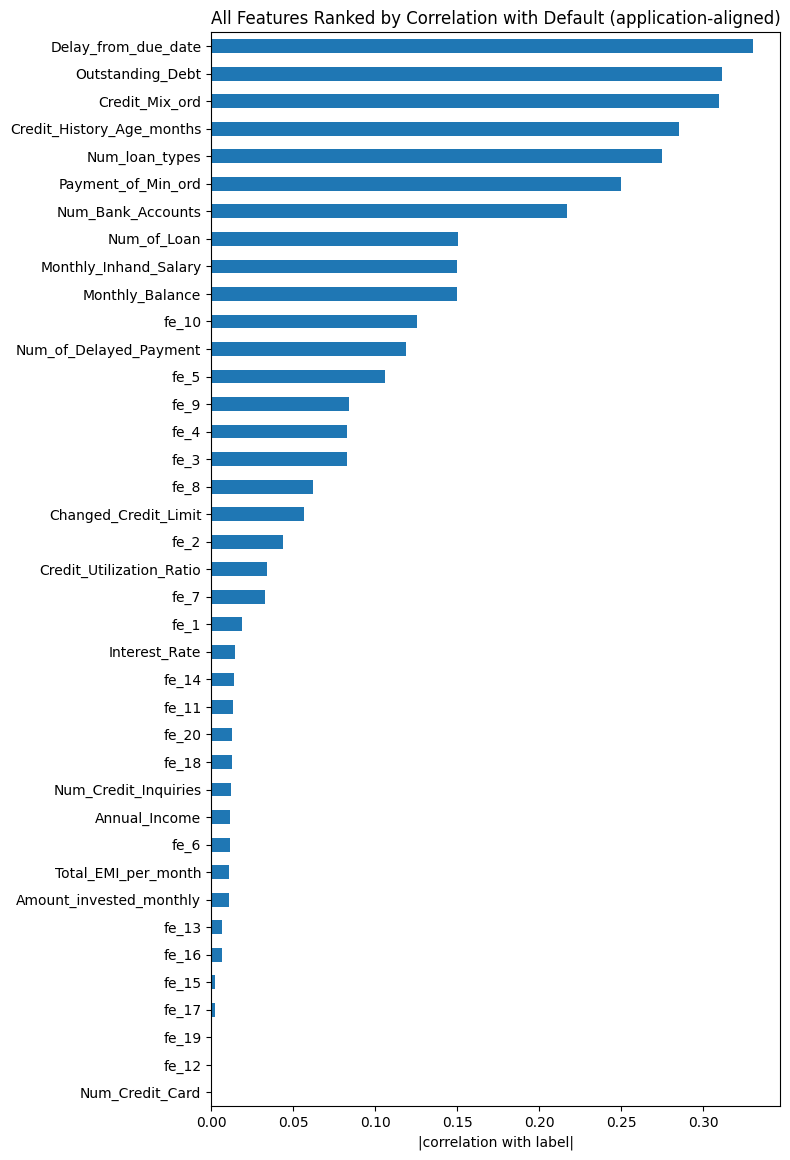

In [28]:
plt.figure(figsize=(8, max(6, len(ranking)*0.3)))
ranking.sort_values().plot(kind='barh')
plt.title('All Features Ranked by Correlation with Default (application-aligned)')
plt.xlabel('|correlation with label|')
plt.tight_layout(); plt.show()

## Build Gold Table - Feature Store
Combine the two cleaned silver sources into a single feature store,
keyed on (Customer_ID, snapshot_date) so it aligns with the label store.
Clickstream (monthly panel) is the backbone; financials is joined as a
customer-level profile by Customer_ID.

In [29]:
# --- selected features from EDA (|correlation with default| >= 0.10) ---
selected_clickstream = ["fe_5", "fe_10"]
selected_financials  = ["Delay_from_due_date", "Outstanding_Debt", "Credit_Mix",
                        "Credit_History_Age_months", "Num_loan_types", "Payment_of_Min_Amount",
                        "Num_Bank_Accounts", "Num_of_Loan", "Monthly_Inhand_Salary",
                        "Monthly_Balance", "Num_of_Delayed_Payment"]

def process_gold_feature_store(snapshot_date_str, silver_clickstream_directory, silver_financials_directory, gold_feature_store_directory, spark):
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")

    # clickstream for THIS month only (no future months in any row)
    cs_partition = "silver_feature_clickstream_" + snapshot_date_str.replace('-','_') + '.parquet'
    cs = spark.read.parquet(silver_clickstream_directory + cs_partition)
    cs = cs.select(["Customer_ID","snapshot_date"] + selected_clickstream)

    # financials: POINT-IN-TIME correct — only records known on/before this snapshot_date
    fin = spark.read.parquet(silver_financials_directory + "*.parquet")
    fin = fin.filter(col("snapshot_date") <= snapshot_date)
    w = Window.partitionBy("Customer_ID").orderBy(desc("snapshot_date"))
    fin = fin.withColumn("rn", row_number().over(w)).filter(col("rn") == 1)
    fin = fin.select(["Customer_ID"] + selected_financials)

    # join selected clickstream + selected financial profile
    df = cs.join(fin, on="Customer_ID", how="left")

    # tidy column order: keys -> financial features -> clickstream features
    df = df.select(["Customer_ID","snapshot_date"] + selected_financials + selected_clickstream)

    # save gold feature store partition
    partition_name = "gold_feature_store_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = gold_feature_store_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath, 'row count:', df.count())

    return df

In [32]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number, desc, col
# create gold feature store directory
gold_feature_store_directory = "datamart/gold/feature_store/"

if not os.path.exists(gold_feature_store_directory):
    os.makedirs(gold_feature_store_directory)

# run gold backfill
for date_str in dates_str_lst:
    process_gold_feature_store(date_str, silver_clickstream_directory, silver_financials_directory, gold_feature_store_directory, spark)

saved to: datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_02_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_03_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_04_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_05_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_06_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_07_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_08_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_09_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_10_01.parquet row count: 8974
saved to: datamart/gold/feature_store/gold_feature_store_2023_11_01.parquet row 

In [33]:
fs_files = [gold_feature_store_directory+os.path.basename(f) for f in glob.glob(gold_feature_store_directory+'*')]
df = spark.read.parquet(*fs_files)
print("feature store row_count:", df.count(), "| num columns:", len(df.columns))
df.limit(5).toPandas()

feature store row_count: 215376 | num columns: 15


,Customer_ID,snapshot_date,Delay_from_due_date,Outstanding_Debt,Credit_Mix,Credit_History_Age_months,Num_loan_types,Payment_of_Min_Amount,Num_Bank_Accounts,Num_of_Loan,Monthly_Inhand_Salary,Monthly_Balance,Num_of_Delayed_Payment,fe_5,fe_10
0,CUS_0x1037,2024-08-01,13,665.820007,Good,237,5,No,5,4,1086.423706,284.380127,15,93,117
1,CUS_0x1069,2024-08-01,9,208.800003,Standard,368,4,Yes,4,50,4799.444824,434.848877,17,-71,59
2,CUS_0x114a,2024-08-01,14,642.419983,Good,189,3,No,0,2,1230.454956,327.965363,2,155,81
3,CUS_0x1184,2024-08-01,10,707.289978,Good,392,4,No,3,3,1396.622925,313.594452,9,221,112
4,CUS_0x1297,2024-08-01,61,3916.469971,Bad,164,10,Yes,9,9,4881.504883,388.045197,24,166,59
